```python 
    # qwen3-vl
    def apply_interleaved_mrope(self, freqs, mrope_section):
        """Apply interleaved MRoPE to 3D rotary embeddings.
        Reorganizes frequency layout from chunked [TTT...HHH...WWW] to
        interleaved [THWTHWTHW...TT], preserving frequency continuity.
        args:
            x: (3, bs, seq_len, head_dim // 2)
            mrope_section: (3,)
        returns:
            x_t: (bs, seq_len, head_dim // 2)
        """
        freqs_t = freqs[0]  # just overwrite the first dimension T
        for dim, offset in enumerate((1, 2), start=1):  # H, W
            length = mrope_section[dim] * 3
            idx = slice(offset, length, 3)
            freqs_t[..., idx] = freqs[dim, ..., idx]
        return freqs_t

    # qwen2.5-vl
    def apply_multimodal_rotary_pos_emb(q, k, cos, sin, mrope_section, unsqueeze_dim=1):
        """Applies Rotary Position Embedding with Multimodal Sections to the query and key tensors (https://qwenlm.github.io/blog/qwen2-vl/).

        Explanation:
            Multimodal 3D rotary position embedding is an extension to 1D rotary position embedding. The input embedding
            sequence contains vision (images / videos) embedding and text embedding or just contains text embedding. For
            vision embedding part, we apply rotary position embedding on temporal, height and width dimension separately.
            Here we split the channel dimension to 3 chunks for the temporal, height and width rotary position embedding.
            For text embedding part, we just apply 1D rotary position embedding. The three rotary position index (temporal,
            height and width) of text embedding is always the same, so the text embedding rotary position embedding has no
            difference with modern LLMs.
        ......
        """
        mrope_section = mrope_section * 2
        cos = torch.cat([m[i % 3] for i, m in enumerate(cos.split(mrope_section, dim=-1))], dim=-1).unsqueeze(
            unsqueeze_dim
        )
        sin = torch.cat([m[i % 3] for i, m in enumerate(sin.split(mrope_section, dim=-1))], dim=-1).unsqueeze(
            unsqueeze_dim
        )

        q_embed = (q * cos) + (rotate_half(q) * sin)
        k_embed = (k * cos) + (rotate_half(k) * sin)
        return q_embed, k_embed
```

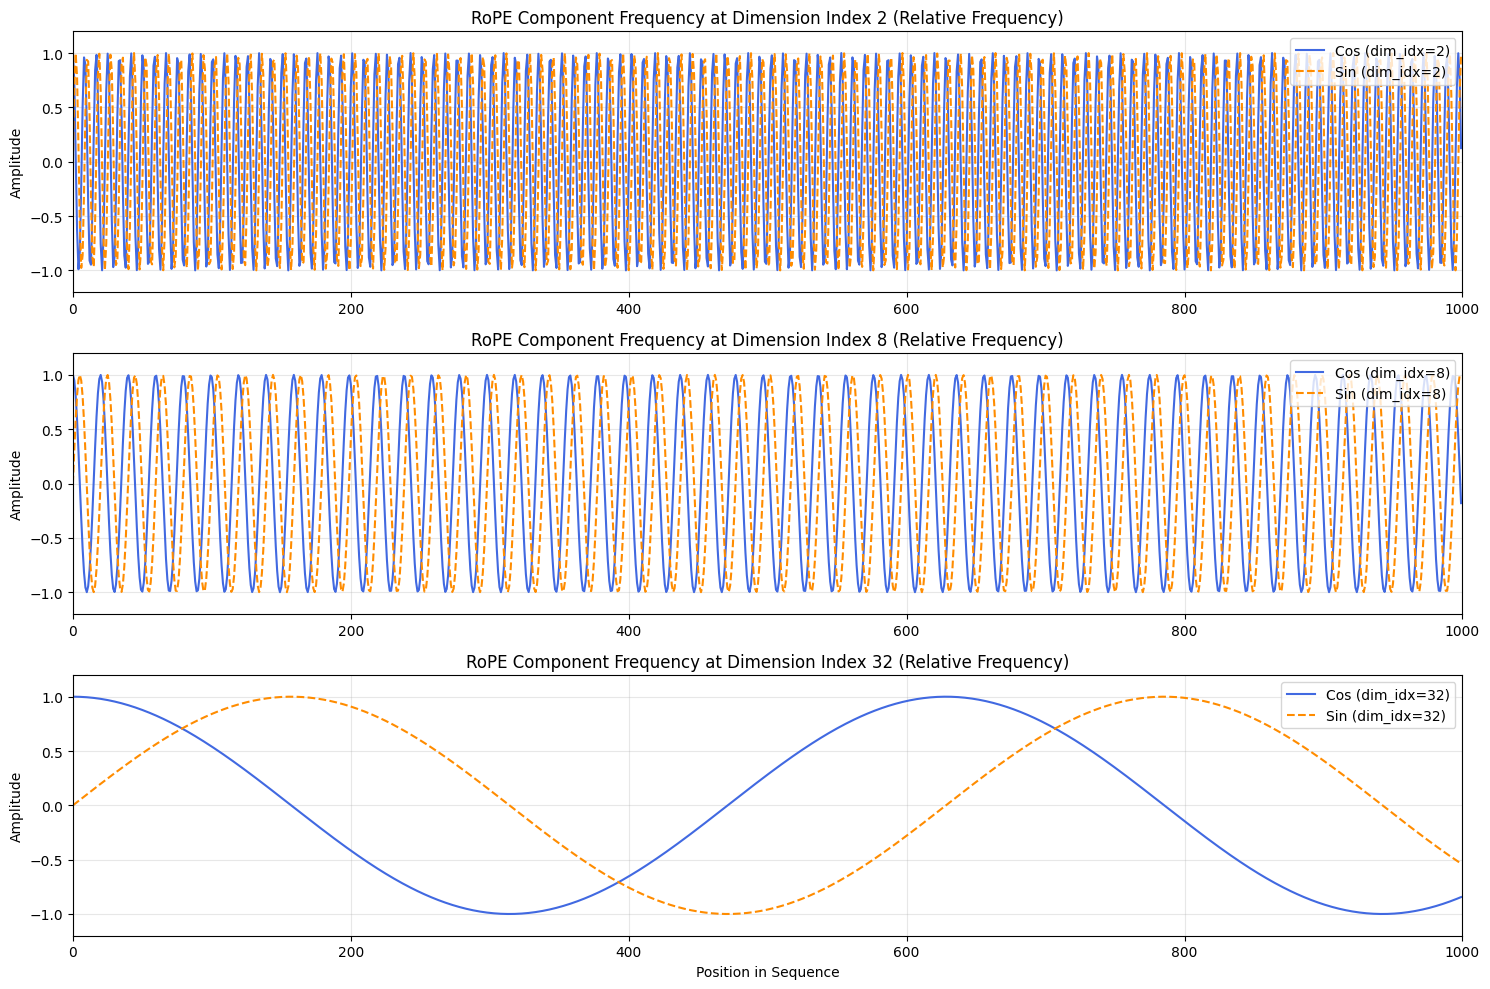

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def get_rope_values(seq_len, dim_index, total_dim, base):
    # 计算特定维度的频率 theta
    theta = 1.0 / (base ** (2 * dim_index / total_dim))
    position = np.arange(seq_len)
    angles = position * theta
    return np.cos(angles), np.sin(angles)

# 参数设置
seq_len = 1000  # 序列长度
total_dim = 128 # 总维度
indices = [2, 8, 32] # 选择三个不同的维度索引进行对比 (高频到低频)
base = 10000

plt.figure(figsize=(15, 10))

for i, idx in enumerate(indices):
    cos_val, sin_val = get_rope_values(seq_len, idx, total_dim, base)
    
    plt.subplot(len(indices), 1, i+1)
    plt.plot(cos_val, label=f'Cos (dim_idx={idx})', color='royalblue', linewidth=1.5)
    plt.plot(sin_val, label=f'Sin (dim_idx={idx})', color='darkorange', linestyle='--', linewidth=1.5)
    
    plt.title(f"RoPE Component Frequency at Dimension Index {idx} (Relative Frequency)")
    plt.ylabel("Amplitude")
    plt.ylim(-1.2, 1.2)
    plt.xlim(0, 1000)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

plt.xlabel("Position in Sequence")
plt.tight_layout()
plt.show()

- 高频维度 (Index 0): 波形极其密集。这意味着只要 Token 稍微移动一个位置，其编码值就会发生剧烈变化。这让模型能够识别相邻 Token 的精确顺序（比如单词的语法结构）。

- 中频维度 (Index 8): 波形变得平滑。它能帮助模型识别短句或短段落内的相对位置。

- 低频维度 (Index 32 及以上): 波形在 1000 个长度内几乎是一条直线或缓慢的弧线。这种低频信息在长文本中至关重要，它提供了全局导航，让模型知道这个词是在文档的开头还是结尾。

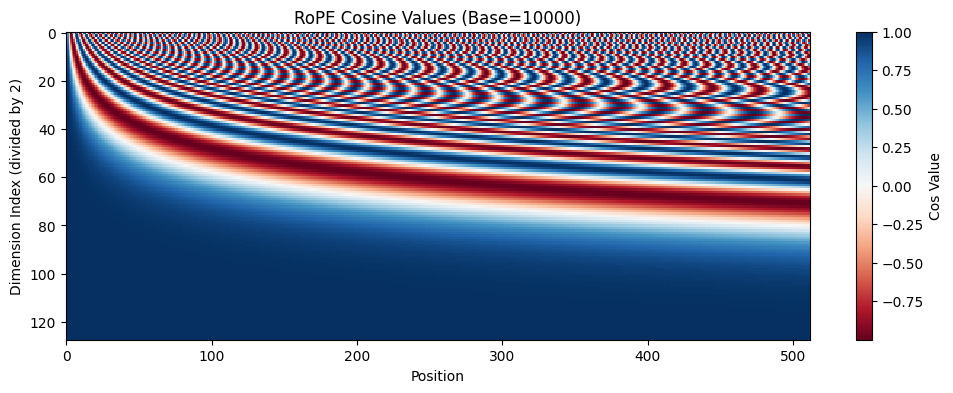

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def plot_rope_heatmap(seq_len=512, total_dim=256, base=10000):
    # 计算所有维度的 theta
    dim_indices = np.arange(0, total_dim, 2) # RoPE通常成对出现
    thetas = 1.0 / (base ** (dim_indices / total_dim))
    
    positions = np.arange(seq_len)
    # 计算角度矩阵 (seq_len, total_dim/2)
    angles = np.outer(positions, thetas)
    cos_map = np.cos(angles).T # 转置以便纵轴代表维度
    
    plt.figure(figsize=(12,4))
    plt.imshow(cos_map, aspect='auto', cmap='RdBu', interpolation='nearest')
    plt.colorbar(label="Cos Value")
    plt.title(f"RoPE Cosine Values (Base={base})")
    plt.xlabel("Position")
    plt.ylabel("Dimension Index (divided by 2)")
    plt.show()

plot_rope_heatmap()